# Importing dataset by adding kaggle

In [2]:
!pip install -q keras-tuner kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 6.7 MB/s eta 0:00:00


In [3]:
import os
import json
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    auc
)

import keras_tuner as kt

import warnings
warnings.filterwarnings("ignore")

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [4]:
print("TensorFlow version:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("GPU is available!")
    print(gpus)
else:
    print("GPU is NOT available. Enable GPU from Runtime > Change runtime type.")

TensorFlow version: 2.20.0
GPU is available!
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:
!pip install -q -U kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.5/262.5 kB 23.2 MB/s eta 0:00:00


In [7]:
import os
from google.colab import userdata

os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")

print("Kaggle API token loaded successfully!")

Kaggle API token loaded successfully!


In [8]:
!kaggle datasets list --max-size 5

ref                                                               title                                                      size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------------------------------  --------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
anhadmahajan06/ps-s6e8predicting-smartphone-addiction-submission  PS S6E8|Predicting Smartphone Addiction Submission     64532018  2026-08-10 14:11:40.307000             81          1                1  
chrissyserb/credit-firewall-signal-detected                       Credit Firewall™ Signal Detected                              0  2026-07-13 05:30:47.760000            325          5                1  
mczielinski/bitcoin-historical-data                               Bitcoin Historical Data                               109459015  2026-08-15 00:40:35.933000         293215       4103     

In [9]:
!kaggle datasets download -d pranavraikokte/covid19-image-dataset

Dataset URL: https://www.kaggle.com/datasets/pranavraikokte/covid19-image-dataset
License(s): CC-BY-SA-4.0
100% 158M/158M [00:04<00:00, 37.6MB/s]



In [11]:
!unzip -q covid19-image-dataset -d covid19_data

In [12]:
import os

for root, dirs, files in os.walk("/content/covid19_data"):
    level = root.replace("/content/covid19_data", "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files[:10]:
        print(f"{indent}    {file}")

covid19_data/
    Covid19-dataset/
        train/
            Viral Pneumonia/
                053.jpeg
                021.jpeg
                073.jpeg
                042.jpeg
                011.jpeg
                03.jpeg
                064.jpeg
                043.jpeg
                032.jpeg
                04.jpeg
            Normal/
                053.jpeg
                021.jpeg
                069.jpeg
                073.jpeg
                011.jpeg
                03.jpeg
                064.jpeg
                050.jpeg
                085.jpeg
                060.jpeg
            Covid/
                053.jpeg
                021.jpeg
                COVID-00021.jpg
                049.jpeg
                019.png
                COVID-00037.jpg
                042.jpeg
                090.jpeg
                03.jpeg
                043.jpeg
        test/
            Viral Pneumonia/
                0110.jpeg
                0111.jpeg
                0109.jpeg
  

In [14]:
import os

BASE_DIR = "/content/covid19_data/Covid19-dataset"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR = os.path.join(BASE_DIR, "test")

print("Training directory:", TRAIN_DIR)
print("Testing directory:", TEST_DIR)

Training directory: /content/covid19_data/Covid19-dataset/train
Testing directory: /content/covid19_data/Covid19-dataset/test


In [15]:
from pathlib import Path

def count_images(folder):
    extensions = {".jpg", ".jpeg", ".png"}

    counts = {}

    for class_folder in Path(folder).iterdir():
        if class_folder.is_dir():
            count = sum(
                1 for file in class_folder.iterdir()
                if file.suffix.lower() in extensions
            )
            counts[class_folder.name] = count

    return counts


train_counts = count_images(TRAIN_DIR)
test_counts = count_images(TEST_DIR)

print("Training images:")
for class_name, count in train_counts.items():
    print(f"{class_name}: {count}")

print("\nTesting images:")
for class_name, count in test_counts.items():
    print(f"{class_name}: {count}")

Training images:
Viral Pneumonia: 70
Normal: 70
Covid: 111

Testing images:
Viral Pneumonia: 20
Normal: 20
Covid: 26


# Importing Libraries

In [16]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc
)

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [17]:
BASE_DIR = "/content/covid19_data/Covid19-dataset"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR = os.path.join(BASE_DIR, "test")

print("Train path:", TRAIN_DIR)
print("Test path:", TEST_DIR)

Train path: /content/covid19_data/Covid19-dataset/train
Test path: /content/covid19_data/Covid19-dataset/test


In [18]:
print("Training classes:", os.listdir(TRAIN_DIR))
print("Testing classes:", os.listdir(TEST_DIR))

Training classes: ['Viral Pneumonia', 'Normal', 'Covid']
Testing classes: ['Viral Pneumonia', 'Normal', 'Covid']


In [19]:
# Loading all images manually
IMG_SIZE = 224

classes = ["Covid", "Normal", "Viral Pneumonia"]

def load_images_from_folder(folder):

    images = []
    labels = []

    for class_name in classes:

        class_path = os.path.join(folder, class_name)

        for filename in os.listdir(class_path):

            image_path = os.path.join(class_path, filename)

            image = cv2.imread(image_path)

            if image is not None:

                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

                images.append(image)
                labels.append(class_name)

    return np.array(images), np.array(labels)

In [20]:
# Loading training and testing images:
X_train_full, y_train_full = load_images_from_folder(TRAIN_DIR)
X_test, y_test = load_images_from_folder(TEST_DIR)

print("Training images:", X_train_full.shape)
print("Testing images:", X_test.shape)

Training images: (251, 224, 224, 3)
Testing images: (66, 224, 224, 3)


In [21]:
# Checking class distribution
print("Training class distribution:")
print(pd.Series(y_train_full).value_counts())

print("\nTesting class distribution:")
print(pd.Series(y_test).value_counts())

Training class distribution:
Covid              111
Normal              70
Viral Pneumonia     70
Name: count, dtype: int64

Testing class distribution:
Covid              26
Normal             20
Viral Pneumonia    20
Name: count, dtype: int64


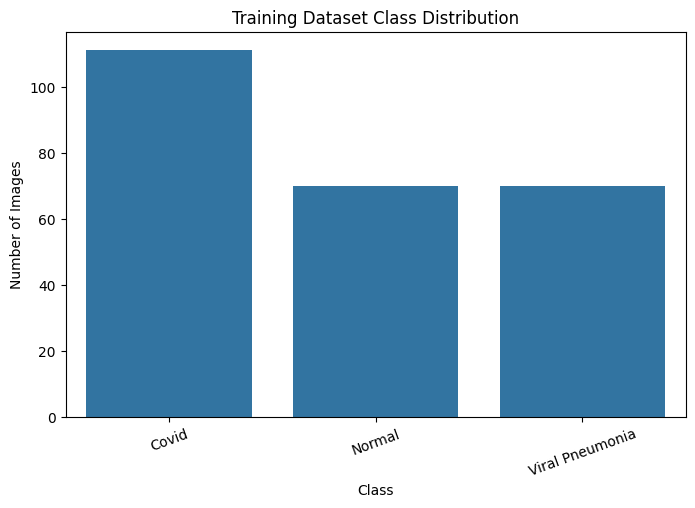

In [22]:
train_distribution = pd.Series(y_train_full).value_counts()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=train_distribution.index,
    y=train_distribution.values
)

plt.title("Training Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=20)
plt.show()

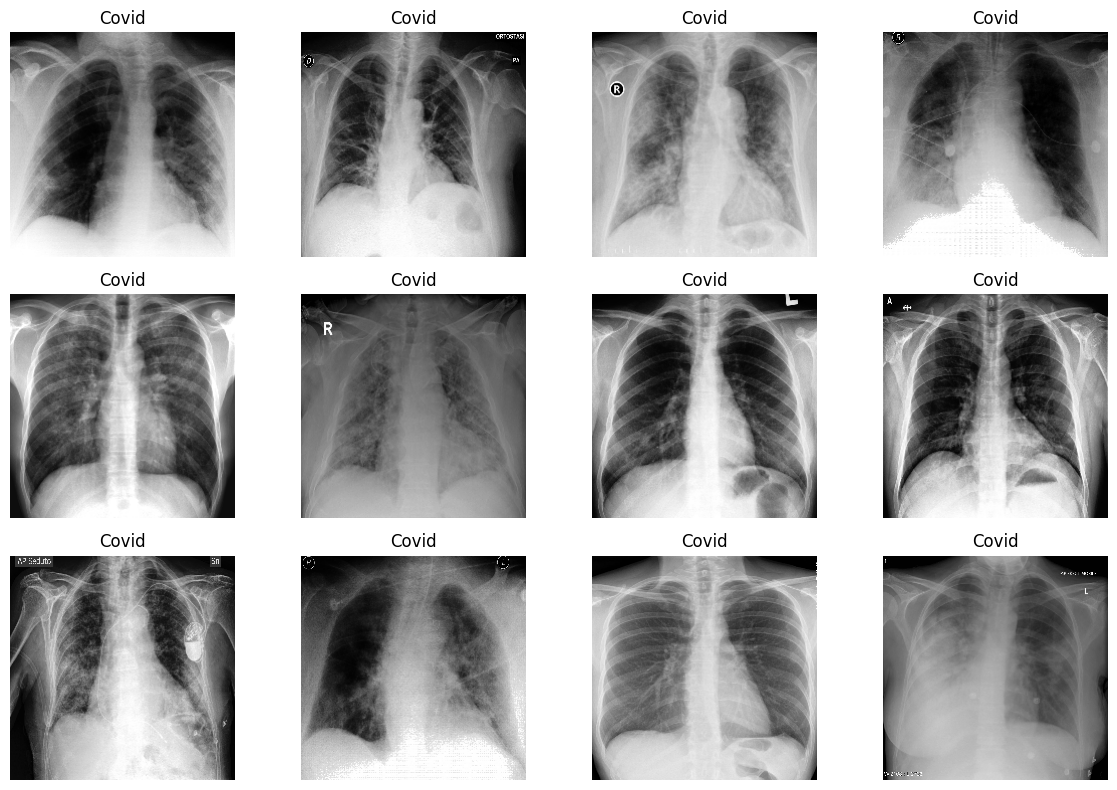

In [23]:
# Displaying sample images
plt.figure(figsize=(12, 8))

for i in range(12):

    plt.subplot(3, 4, i + 1)

    plt.imshow(X_train_full[i])
    plt.title(y_train_full[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

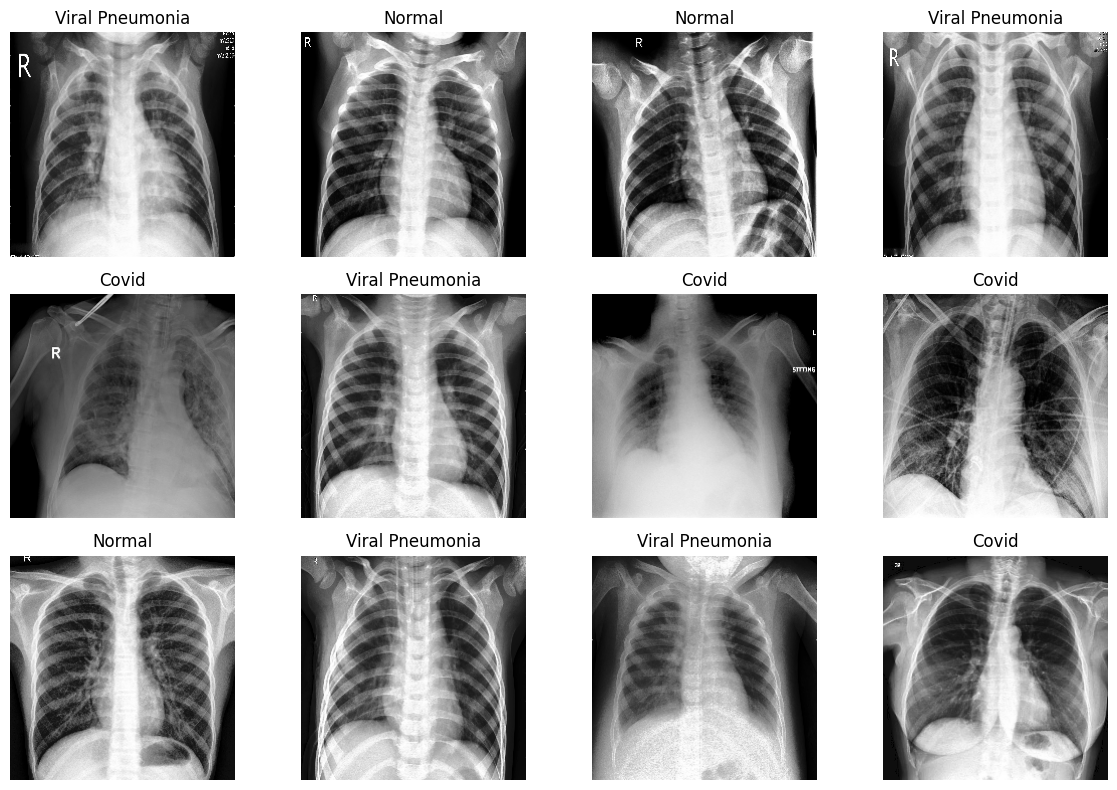

In [24]:
# Random samples
plt.figure(figsize=(12, 8))

random_indices = np.random.choice(
    len(X_train_full),
    12,
    replace=False
)

for i, idx in enumerate(random_indices):

    plt.subplot(3, 4, i + 1)

    plt.imshow(X_train_full[idx])
    plt.title(y_train_full[idx])
    plt.axis("off")

plt.tight_layout()
plt.show()


# Normalizing the images

In [25]:
# Scaling pixel values from 0–255 to 0–1.
X_train_full = X_train_full.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Minimum pixel value:", X_train_full.min())
print("Maximum pixel value:", X_train_full.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [26]:
# One Hot encoding
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train_full)
y_test_encoded = label_encoder.transform(y_test)

print("Classes:", label_encoder.classes_)

Classes: ['Covid' 'Normal' 'Viral Pneumonia']


In [27]:
y_train_onehot = keras.utils.to_categorical(
    y_train_encoded,
    num_classes=3
)

y_test_onehot = keras.utils.to_categorical(
    y_test_encoded,
    num_classes=3
)

print(y_train_onehot.shape)
print(y_test_onehot.shape)

(251, 3)
(66, 3)


# Createing training and validation sets

In [29]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_onehot,
    test_size=0.20,
    random_state=42,
    stratify=y_train_encoded
)

In [30]:
print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)

Training: (200, 224, 224, 3)
Validation: (51, 224, 224, 3)
Testing: (66, 224, 224, 3)


# Building Model 1: Basic CNN

In [31]:
basic_cnn = models.Sequential([

    layers.Input(shape=(224, 224, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(3, activation="softmax")
])

basic_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,907,779 (91.20 MB)

 Trainable params: 23,907,779 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
basic_cnn.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [33]:
# Training Basic CNN
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [35]:
# Training
history_basic = basic_cnn.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stopping]
)

Epoch 1/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 921ms/step - accuracy: 0.4450 - loss: 4.1008 - val_accuracy: 0.6667 - val_loss: 0.9464
Epoch 2/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.7250 - loss: 0.7437 - val_accuracy: 0.9020 - val_loss: 0.4382
Epoch 3/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.8700 - loss: 0.3522 - val_accuracy: 0.9020 - val_loss: 0.2509
Epoch 4/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9550 - loss: 0.1483 - val_accuracy: 0.8824 - val_loss: 0.2853
Epoch 5/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.9500 - loss: 0.1166 - val_accuracy: 0.9412 - val_loss: 0.1899
Epoch 6/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9600 - loss: 0.1031 - val_accuracy: 0.9216 - val_loss: 0.2126
Epoch 7/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9850 - loss: 0.0595 - val_accuracy: 0.8824 - val_loss: 0.2066
Epoch 8/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9850 - loss: 0.0511 - val_accuracy: 0.9216 - val_loss: 0.226

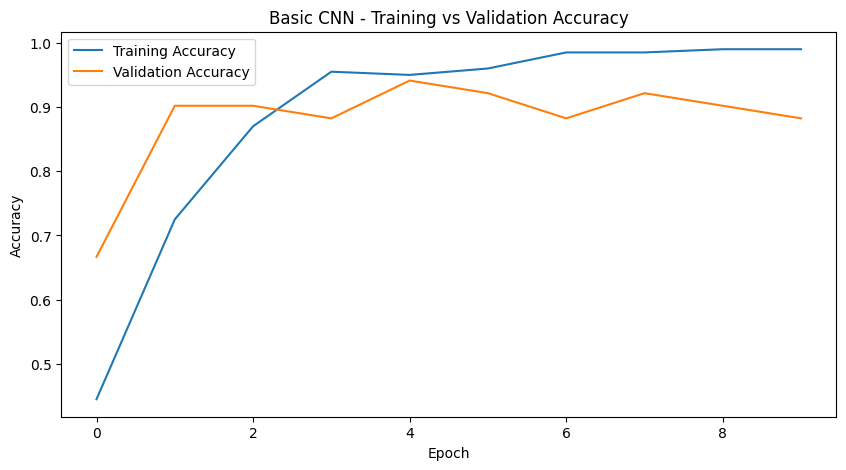

In [36]:
# Plotting CNN performence
plt.figure(figsize=(10, 5))

plt.plot(
    history_basic.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_basic.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Basic CNN - Training vs Validation Accuracy")
plt.legend()
plt.show()

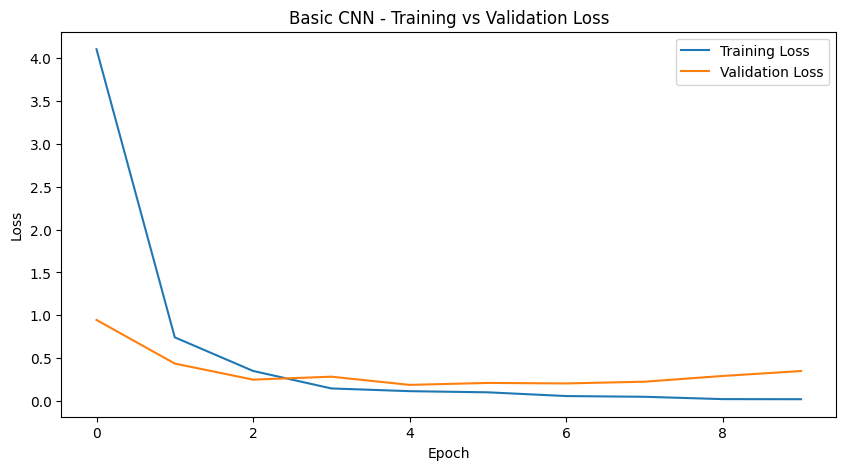

In [38]:
# Loss
plt.figure(figsize=(10, 5))

plt.plot(
    history_basic.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_basic.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Basic CNN - Training vs Validation Loss")
plt.legend()
plt.show()

# Evaluating Basic CNN

In [39]:
test_loss, test_accuracy = basic_cnn.evaluate(
    X_test,
    y_test_onehot,
    verbose=1
)

print("Basic CNN Test Accuracy:", test_accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 483ms/step - accuracy: 0.8939 - loss: 0.2725
Basic CNN Test Accuracy: 0.8939393758773804


In [40]:
# Predictions
y_pred_prob = basic_cnn.predict(X_test)

y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test_onehot, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 254ms/step


In [41]:
# Classification report
print(
    classification_report(
        y_true,
        y_pred,
        target_names=label_encoder.classes_
    )
)

                 precision    recall  f1-score   support

          Covid       1.00      0.96      0.98        26
         Normal       0.78      0.90      0.84        20
Viral Pneumonia       0.89      0.80      0.84        20

       accuracy                           0.89        66
      macro avg       0.89      0.89      0.89        66
   weighted avg       0.90      0.89      0.90        66



In [42]:
# f1
basic_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print("Basic CNN F1 Score:", basic_f1)

Basic CNN F1 Score: 0.8950982937591043


# Confusion matrix

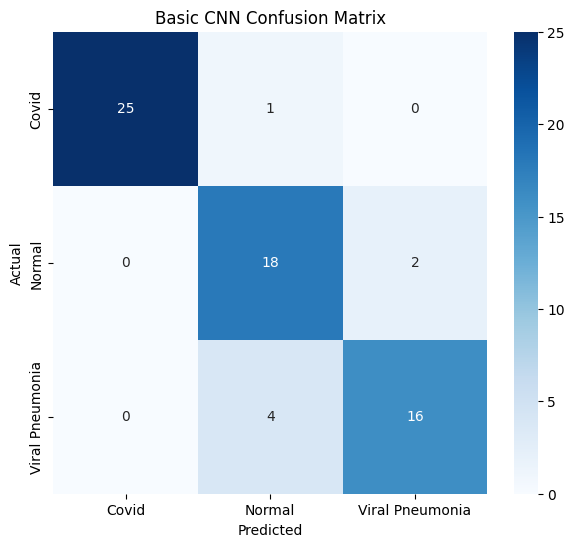

In [43]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Basic CNN Confusion Matrix")
plt.show()

# ROC-AUC

In [44]:
basic_auc = roc_auc_score(
    y_test_onehot,
    y_pred_prob,
    multi_class="ovr",
    average="weighted"
)

print("Basic CNN ROC-AUC:", basic_auc)

Basic CNN ROC-AUC: 0.9706357048748354


# Building the Deep CNN

In [45]:
from tensorflow.keras import layers, models

deep_cnn = models.Sequential([

    layers.Input(shape=(224, 224, 3)),

    # Block 1
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 2
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 3
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 4
    layers.Conv2D(256, (3, 3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Classification
    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(3, activation="softmax")
])

deep_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,619 (1.62 MB)

 Trainable params: 422,659 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [47]:
# Compiling
deep_cnn.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [48]:
early_stopping_deep = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [49]:
# Training
history_deep = deep_cnn.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stopping_deep]
)

Epoch 1/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.5650 - loss: 0.9367 - val_accuracy: 0.2745 - val_loss: 1.1328
Epoch 2/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.7050 - loss: 0.6284 - val_accuracy: 0.4314 - val_loss: 1.0605
Epoch 3/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.7750 - loss: 0.5212 - val_accuracy: 0.4510 - val_loss: 1.0900
Epoch 4/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.8350 - loss: 0.4393 - val_accuracy: 0.4510 - val_loss: 1.2192
Epoch 5/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.8700 - loss: 0.3375 - val_accuracy: 0.4510 - val_loss: 1.4992
Epoch 6/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.9150 - loss: 0.2903 - val_accuracy: 0.4510 - val_loss: 2.0764
Epoch 7/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.8900 - loss: 0.2861 - val_accuracy: 0.4510 - val_loss: 2.6571


# Plotting Deep CNN

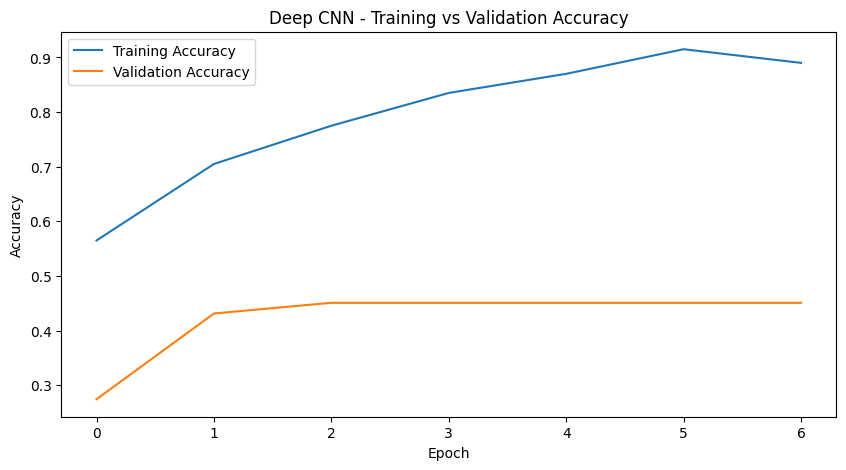

In [50]:
# Accuracy
plt.figure(figsize=(10, 5))

plt.plot(
    history_deep.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_deep.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Deep CNN - Training vs Validation Accuracy")
plt.legend()
plt.show()

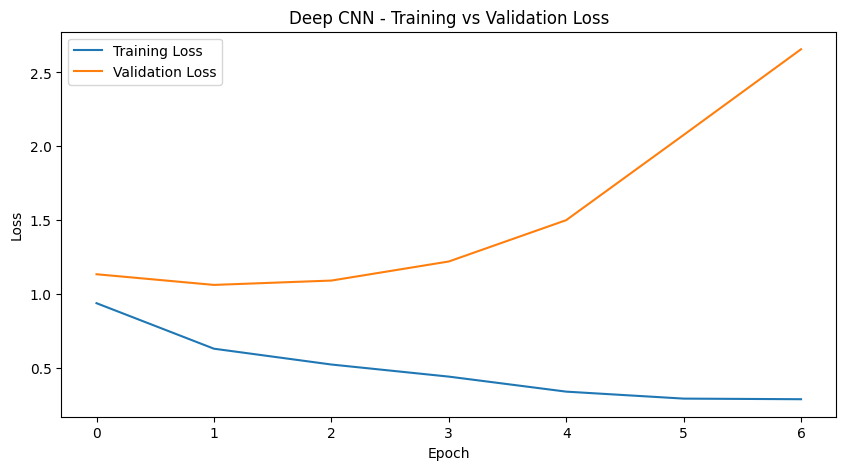

In [51]:
# Loss
plt.figure(figsize=(10, 5))

plt.plot(
    history_deep.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_deep.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Deep CNN - Training vs Validation Loss")
plt.legend()
plt.show()

In [52]:
deep_test_loss, deep_test_accuracy = deep_cnn.evaluate(
    X_test,
    y_test_onehot,
    verbose=1
)

print("Deep CNN Test Accuracy:", deep_test_accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 547ms/step - accuracy: 0.3939 - loss: 1.0797
Deep CNN Test Accuracy: 0.39393940567970276


In [53]:
deep_pred_prob = deep_cnn.predict(X_test)

deep_pred = np.argmax(deep_pred_prob, axis=1)
deep_true = np.argmax(y_test_onehot, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 456ms/step


In [54]:
# Classification report
print(
    classification_report(
        deep_true,
        deep_pred,
        target_names=label_encoder.classes_
    )
)

                 precision    recall  f1-score   support

          Covid       0.39      1.00      0.57        26
         Normal       0.00      0.00      0.00        20
Viral Pneumonia       0.00      0.00      0.00        20

       accuracy                           0.39        66
      macro avg       0.13      0.33      0.19        66
   weighted avg       0.16      0.39      0.22        66



In [55]:
# f1 score
deep_f1 = f1_score(
    deep_true,
    deep_pred,
    average="weighted"
)

print("Deep CNN F1 Score:", deep_f1)

Deep CNN F1 Score: 0.22266139657444003


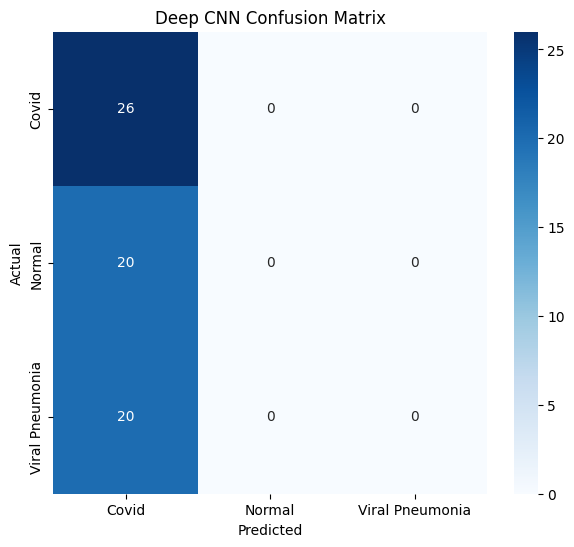

In [56]:
# Ci=onfusion matrix
deep_cm = confusion_matrix(
    deep_true,
    deep_pred
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    deep_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Deep CNN Confusion Matrix")
plt.show()

In [57]:
# ROC-AUC
deep_auc = roc_auc_score(
    y_test_onehot,
    deep_pred_prob,
    multi_class="ovr",
    average="weighted"
)

print("Deep CNN ROC-AUC:", deep_auc)

Deep CNN ROC-AUC: 0.7263833992094861


# Results for Deep CNN

In [58]:
print("========== DEEP CNN RESULTS ==========")
print("Train Accuracy:", history_deep.history["accuracy"][-1])
print("Test Accuracy:", deep_test_accuracy)
print("F1 Score:", deep_f1)
print("ROC-AUC:", deep_auc)

========== DEEP CNN RESULTS ==========
Train Accuracy: 0.8899999856948853
Test Accuracy: 0.39393940567970276
F1 Score: 0.22266139657444003
ROC-AUC: 0.7263833992094861


In [59]:
train_acc_deep = history_deep.history["accuracy"][-1]
val_acc_deep = history_deep.history["val_accuracy"][-1]

gap_deep = train_acc_deep - val_acc_deep

print("Training Accuracy:", train_acc_deep)
print("Validation Accuracy:", val_acc_deep)
print("Overfitting Gap:", gap_deep)

if gap_deep > 0.10:
    print("Potential overfitting: YES")
else:
    print("Significant overfitting: NO")

Training Accuracy: 0.8899999856948853
Validation Accuracy: 0.45098039507865906
Overfitting Gap: 0.4390195906162262
Potential overfitting: YES


# Transfer Learning: VGG16

In [60]:
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input

In [61]:
# base model
vgg_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [62]:
vgg_base.trainable = False

In [63]:
# Creating classifier
vgg_model = models.Sequential([

    vgg_base,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(3, activation="softmax")
])

vgg_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,739 (56.38 MB)

 Trainable params: 66,051 (258.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [64]:
# Converting normalized images back to 0-255
X_train_vgg = X_train_full * 255.0
X_test_vgg = X_test * 255.0

# Making sure the datatype is float32
X_train_vgg = X_train_vgg.astype("float32")
X_test_vgg = X_test_vgg.astype("float32")

print("Training shape:", X_train_vgg.shape)
print("Testing shape:", X_test_vgg.shape)

Training shape: (251, 224, 224, 3)
Testing shape: (66, 224, 224, 3)


In [65]:
# splitting the training data into training and validation
from sklearn.model_selection import train_test_split

y_train_vgg_labels = np.argmax(y_train_onehot, axis=1)

X_train_vgg, X_val_vgg, y_train_vgg, y_val_vgg = train_test_split(
    X_train_vgg,
    y_train_onehot,
    test_size=0.20,
    random_state=42,
    stratify=y_train_vgg_labels
)

print("VGG16 Training:", X_train_vgg.shape)
print("VGG16 Validation:", X_val_vgg.shape)
print("VGG16 Testing:", X_test_vgg.shape)

VGG16 Training: (200, 224, 224, 3)
VGG16 Validation: (51, 224, 224, 3)
VGG16 Testing: (66, 224, 224, 3)


In [66]:
# processing
X_train_vgg = preprocess_input(X_train_vgg)
X_val_vgg = preprocess_input(X_val_vgg)
X_test_vgg = preprocess_input(X_test_vgg)

In [67]:
from tensorflow.keras.applications import VGG16

vgg_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

print("VGG16 loaded successfully!")

VGG16 loaded successfully!


In [68]:
vgg_base.trainable = False

print("Trainable layers:", sum(layer.trainable for layer in vgg_base.layers))

Trainable layers: 0


In [69]:
# Model building
from tensorflow.keras import layers, models

vgg_model = models.Sequential([

    vgg_base,

    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation="relu"),

    layers.Dropout(0.5),

    layers.Dense(3, activation="softmax")
])

vgg_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,787 (56.64 MB)

 Trainable params: 132,099 (516.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [70]:
# Compiling
vgg_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [71]:
# Early stopping
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

vgg_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

vgg_checkpoint = ModelCheckpoint(
    "best_vgg16.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)

In [72]:
# Training
history_vgg = vgg_model.fit(
    X_train_vgg,
    y_train_vgg,
    validation_data=(X_val_vgg, y_val_vgg),
    epochs=20,
    batch_size=32,
    callbacks=[
        vgg_early_stopping,
        vgg_checkpoint
    ]
)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 42s 3s/step - accuracy: 0.4500 - loss: 3.4613 - val_accuracy: 0.8627 - val_loss: 0.5339
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 238ms/step - accuracy: 0.8000 - loss: 1.0773 - val_accuracy: 0.8627 - val_loss: 0.8214
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 334ms/step - accuracy: 0.8200 - loss: 0.9424 - val_accuracy: 0.9412 - val_loss: 0.4059
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 236ms/step - accuracy: 0.9200 - loss: 0.3910 - val_accuracy: 0.8824 - val_loss: 0.5563
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 235ms/step - accuracy: 0.9350 - loss: 0.3501 - val_accuracy: 0.9216 - val_loss: 0.4196
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 245ms/step - accuracy: 0.9250 - loss: 0.3701 - val_accuracy: 0.9216 - val_loss: 0.3608
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 242ms/step - accuracy: 0.9200 - loss: 0.3184 - val_accuracy: 0.9216 - val_loss: 0.4318
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 231ms/step - accuracy: 0.9450 - loss: 0.1776 - val_accuracy: 0.9216 - val_loss: 0

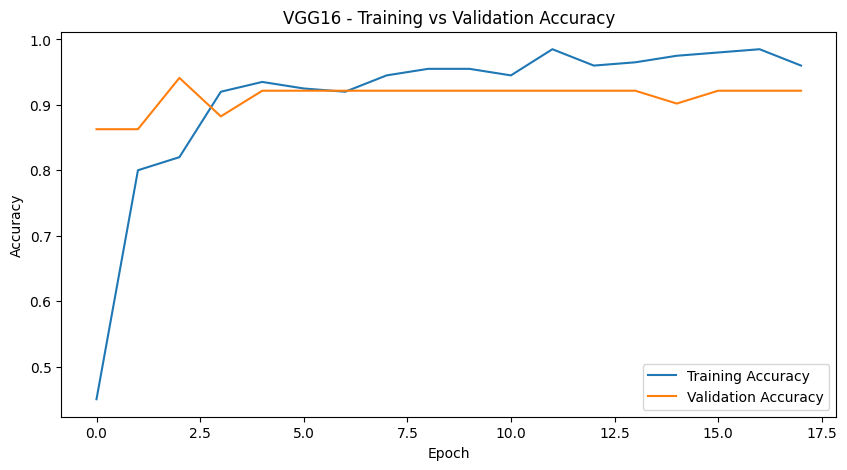

In [73]:
# Plotting accuracy
plt.figure(figsize=(10, 5))

plt.plot(
    history_vgg.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_vgg.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("VGG16 - Training vs Validation Accuracy")
plt.legend()
plt.show()

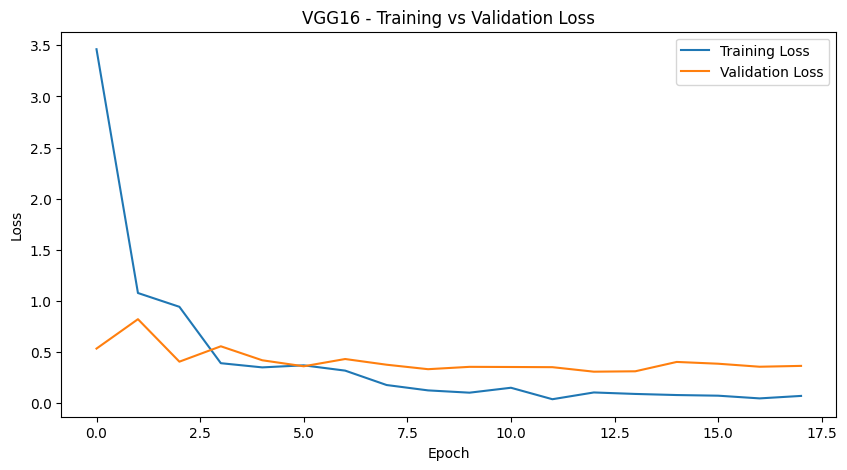

In [74]:
# Plotting losss
plt.figure(figsize=(10, 5))

plt.plot(
    history_vgg.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_vgg.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VGG16 - Training vs Validation Loss")
plt.legend()
plt.show()

## Fine-tuning the last few VGG16 layers

In [75]:
for i, layer in enumerate(vgg_base.layers):
    print(i, layer.name, layer.trainable)

0 input_layer_4 False
1 block1_conv1 False
2 block1_conv2 False
3 block1_pool False
4 block2_conv1 False
5 block2_conv2 False
6 block2_pool False
7 block3_conv1 False
8 block3_conv2 False
9 block3_conv3 False
10 block3_pool False
11 block4_conv1 False
12 block4_conv2 False
13 block4_conv3 False
14 block4_pool False
15 block5_conv1 False
16 block5_conv2 False
17 block5_conv3 False
18 block5_pool False


In [76]:
# Freezing everything except last 4 layers
vgg_base.trainable = True

for layer in vgg_base.layers[:-4]:
    layer.trainable = False

for layer in vgg_base.layers[-4:]:
    layer.trainable = True

In [77]:
# Cheaking
print("Trainable VGG16 layers:")

for layer in vgg_base.layers:
    if layer.trainable:
        print(layer.name)

Trainable VGG16 layers:
block5_conv1
block5_conv2
block5_conv3
block5_pool


In [78]:
# Recompiling with a low learning rate
from tensorflow.keras.optimizers import Adam

vgg_model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [79]:
# Fine-tunung VGG16
vgg_fine_tune = vgg_model.fit(
    X_train_vgg,
    y_train_vgg,
    validation_data=(X_val_vgg, y_val_vgg),
    epochs=15,
    batch_size=32,
    callbacks=[
        vgg_early_stopping,
        vgg_checkpoint
    ]
)

Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.9650 - loss: 0.0746 - val_accuracy: 0.9216 - val_loss: 0.3714
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 283ms/step - accuracy: 0.9550 - loss: 0.1014 - val_accuracy: 0.9216 - val_loss: 0.4151
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 289ms/step - accuracy: 0.9850 - loss: 0.0466 - val_accuracy: 0.9216 - val_loss: 0.2907
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 284ms/step - accuracy: 0.9900 - loss: 0.0602 - val_accuracy: 0.9216 - val_loss: 0.3505
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 286ms/step - accuracy: 1.0000 - loss: 0.0071 - val_accuracy: 0.9216 - val_loss: 0.4097
Epoch 6/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 285ms/step - accuracy: 0.9850 - loss: 0.0338 - val_accuracy: 0.9216 - val_loss: 0.4801
Epoch 7/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 285ms/step - accuracy: 0.9850 - loss: 0.0459 - val_accuracy: 0.9216 - val_loss: 0.3918
Epoch 8/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 290ms/step - accuracy: 1.0000 - loss: 0.0070 - val_accuracy: 0.9216 - val_loss: 0

In [80]:
# Evaluating
## best saved model
vgg_model.load_weights("best_vgg16.keras")

In [81]:
vgg_test_loss, vgg_test_accuracy = vgg_model.evaluate(
    X_test_vgg,
    y_test_onehot,
    verbose=1
)

print("VGG16 Test Accuracy:", vgg_test_accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.8939 - loss: 0.3418
VGG16 Test Accuracy: 0.8939393758773804


In [82]:
# Generating predictions
vgg_pred_prob = vgg_model.predict(X_test_vgg)

vgg_pred = np.argmax(vgg_pred_prob, axis=1)

vgg_true = np.argmax(y_test_onehot, axis=1)

2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step


In [83]:
# Classification report
print(
    classification_report(
        vgg_true,
        vgg_pred,
        target_names=label_encoder.classes_
    )
)

                 precision    recall  f1-score   support

          Covid       1.00      1.00      1.00        26
         Normal       0.76      0.95      0.84        20
Viral Pneumonia       0.93      0.70      0.80        20

       accuracy                           0.89        66
      macro avg       0.90      0.88      0.88        66
   weighted avg       0.91      0.89      0.89        66



In [84]:
# F1 score
vgg_f1 = f1_score(
    vgg_true,
    vgg_pred,
    average="weighted"
)

print("VGG16 F1 Score:", vgg_f1)

VGG16 F1 Score: 0.8922558922558922


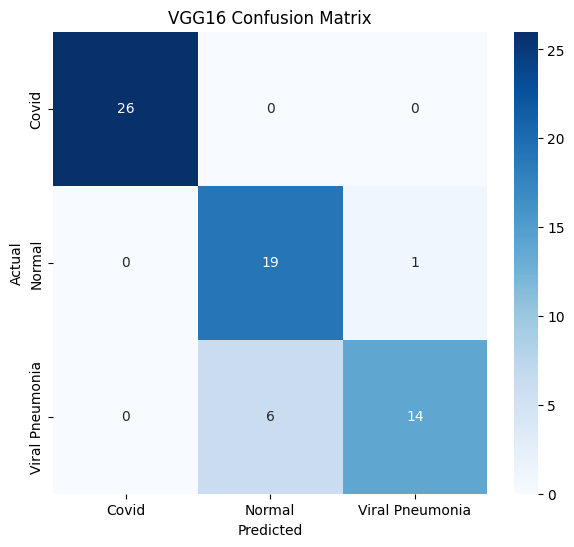

In [85]:
# Confusion matrix
vgg_cm = confusion_matrix(
    vgg_true,
    vgg_pred
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    vgg_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("VGG16 Confusion Matrix")
plt.show()

In [86]:
# ROC-AUC
vgg_auc = roc_auc_score(
    y_test_onehot,
    vgg_pred_prob,
    multi_class="ovr",
    average="weighted"
)

print("VGG16 ROC-AUC:", vgg_auc)

VGG16 ROC-AUC: 0.9749670619235838


In [87]:
# Results
vgg_train_accuracy = vgg_fine_tune.history["accuracy"][-1]
vgg_val_accuracy = vgg_fine_tune.history["val_accuracy"][-1]

vgg_overfitting_gap = vgg_train_accuracy - vgg_val_accuracy

print("========== VGG16 RESULTS ==========")
print("Train Accuracy:", vgg_train_accuracy)
print("Validation Accuracy:", vgg_val_accuracy)
print("Test Accuracy:", vgg_test_accuracy)
print("F1 Score:", vgg_f1)
print("ROC-AUC:", vgg_auc)
print("Overfitting Gap:", vgg_overfitting_gap)

if vgg_overfitting_gap > 0.10:
    print("Overfitting: YES")
else:
    print("Overfitting: NO")

========== VGG16 RESULTS ==========
Train Accuracy: 1.0
Validation Accuracy: 0.9215686321258545
Test Accuracy: 0.8939393758773804
F1 Score: 0.8922558922558922
ROC-AUC: 0.9749670619235838
Overfitting Gap: 0.07843136787414551
Overfitting: NO


# ResNet50 Transfer Learning

In [88]:
# Coverting to original 0-255 value
X_train_resnet = X_train_full * 255.0
X_test_resnet = X_test * 255.0

X_train_resnet = X_train_resnet.astype("float32")
X_test_resnet = X_test_resnet.astype("float32")

print("Training shape:", X_train_resnet.shape)
print("Testing shape:", X_test_resnet.shape)

Training shape: (251, 224, 224, 3)
Testing shape: (66, 224, 224, 3)


In [89]:
# Validation split
y_train_resnet_labels = np.argmax(y_train_onehot, axis=1)

X_train_resnet, X_val_resnet, y_train_resnet, y_val_resnet = train_test_split(
    X_train_resnet,
    y_train_onehot,
    test_size=0.20,
    random_state=42,
    stratify=y_train_resnet_labels
)

print("Training:", X_train_resnet.shape)
print("Validation:", X_val_resnet.shape)
print("Testing:", X_test_resnet.shape)

Training: (200, 224, 224, 3)
Validation: (51, 224, 224, 3)
Testing: (66, 224, 224, 3)


In [90]:
# ResNet50 processing
X_train_resnet = preprocess_input(X_train_resnet)
X_val_resnet = preprocess_input(X_val_resnet)
X_test_resnet = preprocess_input(X_test_resnet)

In [91]:
# loding pretrained ResNet50
resnet_base = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

print("ResNet50 loaded successfully!")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
ResNet50 loaded successfully!


In [92]:
resnet_base.trainable = False

print(
    "Trainable layers:",
    sum(layer.trainable for layer in resnet_base.layers)
)

Trainable layers: 0


In [93]:
# Model building
resnet_model = models.Sequential([

    resnet_base,

    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation="relu"),

    layers.Dropout(0.5),

    layers.Dense(3, activation="softmax")
])

resnet_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,027 (91.98 MB)

 Trainable params: 525,315 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [94]:
# Compiling
resnet_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [95]:
# Creating callbacks
resnet_early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

resnet_checkpoint = keras.callbacks.ModelCheckpoint(
    "best_resnet50.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)

In [96]:
# Training
history_resnet = resnet_model.fit(
    X_train_resnet,
    y_train_resnet,
    validation_data=(X_val_resnet, y_val_resnet),
    epochs=20,
    batch_size=32,
    callbacks=[
        resnet_early_stopping,
        resnet_checkpoint
    ]
)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 32s 3s/step - accuracy: 0.4450 - loss: 2.8780 - val_accuracy: 0.6471 - val_loss: 2.1532
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 291ms/step - accuracy: 0.7350 - loss: 0.8647 - val_accuracy: 0.7843 - val_loss: 0.6506
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 262ms/step - accuracy: 0.8300 - loss: 0.5634 - val_accuracy: 0.8039 - val_loss: 0.6547
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 289ms/step - accuracy: 0.8650 - loss: 0.3682 - val_accuracy: 0.8824 - val_loss: 0.3508
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 338ms/step - accuracy: 0.9200 - loss: 0.2132 - val_accuracy: 0.9020 - val_loss: 0.2869
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step - accuracy: 0.9500 - loss: 0.1457 - val_accuracy: 0.8824 - val_loss: 0.3454
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 150ms/step - accuracy: 0.9500 - loss: 0.1386 - val_accuracy: 0.9020 - val_loss: 0.2506
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - accuracy: 0.9700 - loss: 0.0768 - val_accuracy: 0.9020 - val_loss: 0

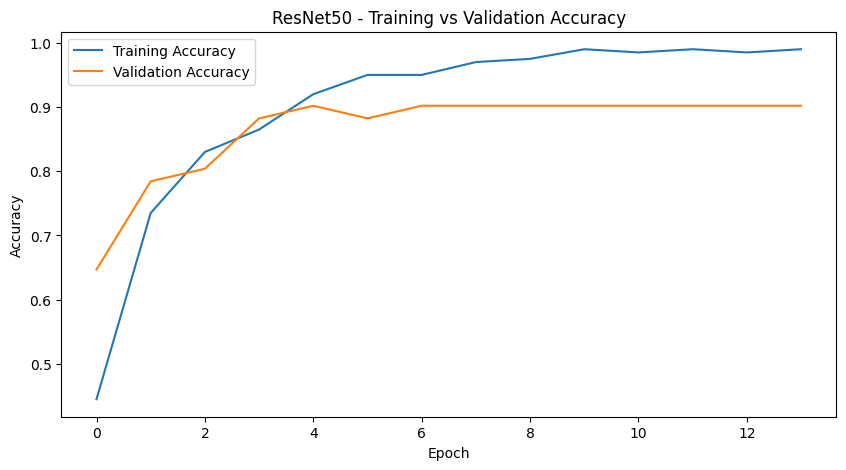

In [97]:
# plotting accuracy
plt.figure(figsize=(10, 5))

plt.plot(
    history_resnet.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_resnet.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet50 - Training vs Validation Accuracy")
plt.legend()
plt.show()

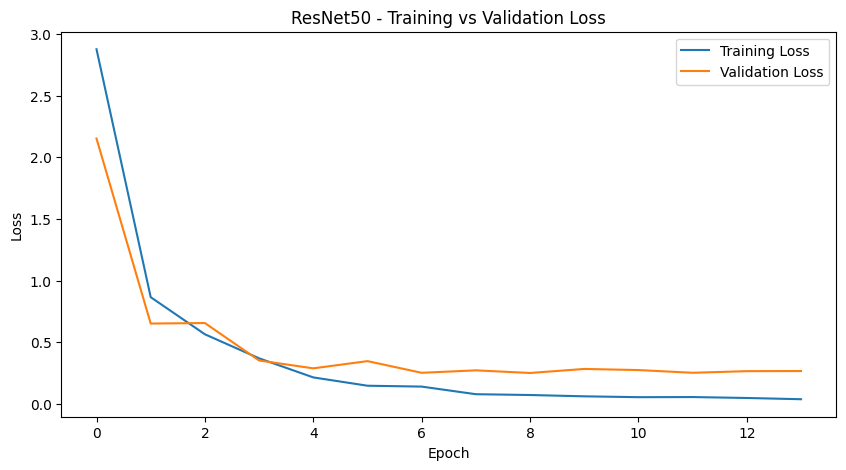

In [98]:
# loss
plt.figure(figsize=(10, 5))

plt.plot(
    history_resnet.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_resnet.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet50 - Training vs Validation Loss")
plt.legend()
plt.show()

In [99]:
# fine tuning
for i, layer in enumerate(resnet_base.layers):
    print(i, layer.name, layer.trainable)

0 input_layer_6 False
1 conv1_pad False
2 conv1_conv False
3 conv1_bn False
4 conv1_relu False
5 pool1_pad False
6 pool1_pool False
7 conv2_block1_1_conv False
8 conv2_block1_1_bn False
9 conv2_block1_1_relu False
10 conv2_block1_2_conv False
11 conv2_block1_2_bn False
12 conv2_block1_2_relu False
13 conv2_block1_0_conv False
14 conv2_block1_3_conv False
15 conv2_block1_0_bn False
16 conv2_block1_3_bn False
17 conv2_block1_add False
18 conv2_block1_out False
19 conv2_block2_1_conv False
20 conv2_block2_1_bn False
21 conv2_block2_1_relu False
22 conv2_block2_2_conv False
23 conv2_block2_2_bn False
24 conv2_block2_2_relu False
25 conv2_block2_3_conv False
26 conv2_block2_3_bn False
27 conv2_block2_add False
28 conv2_block2_out False
29 conv2_block3_1_conv False
30 conv2_block3_1_bn False
31 conv2_block3_1_relu False
32 conv2_block3_2_conv False
33 conv2_block3_2_bn False
34 conv2_block3_2_relu False
35 conv2_block3_3_conv False
36 conv2_block3_3_bn False
37 conv2_block3_add False
38 conv

In [100]:
resnet_base.trainable = True

# Freeze all layers except the last 10
for layer in resnet_base.layers[:-10]:
    layer.trainable = False

# Unfreeze the last 10
for layer in resnet_base.layers[-10:]:
    layer.trainable = True

In [101]:
# cheking
print("Trainable ResNet50 layers:")

for layer in resnet_base.layers:
    if layer.trainable:
        print(layer.name)

Trainable ResNet50 layers:
conv5_block3_1_conv
conv5_block3_1_bn
conv5_block3_1_relu
conv5_block3_2_conv
conv5_block3_2_bn
conv5_block3_2_relu
conv5_block3_3_conv
conv5_block3_3_bn
conv5_block3_add
conv5_block3_out


In [102]:
# Recompiling with low learnong rate
from tensorflow.keras.optimizers import Adam

resnet_model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [103]:
# fine tuning
history_resnet_fine = resnet_model.fit(
    X_train_resnet,
    y_train_resnet,
    validation_data=(X_val_resnet, y_val_resnet),
    epochs=15,
    batch_size=32,
    callbacks=[
        resnet_early_stopping,
        resnet_checkpoint
    ]
)

Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.9650 - loss: 0.0994 - val_accuracy: 0.9216 - val_loss: 0.2399
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step - accuracy: 0.9900 - loss: 0.0719 - val_accuracy: 0.9216 - val_loss: 0.2354
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 159ms/step - accuracy: 0.9900 - loss: 0.0591 - val_accuracy: 0.9216 - val_loss: 0.2325
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 159ms/step - accuracy: 0.9900 - loss: 0.0627 - val_accuracy: 0.9216 - val_loss: 0.2297
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 390ms/step - accuracy: 0.9950 - loss: 0.0598 - val_accuracy: 0.9412 - val_loss: 0.2287
Epoch 6/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 163ms/step - accuracy: 0.9950 - loss: 0.0461 - val_accuracy: 0.9412 - val_loss: 0.2284
Epoch 7/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step - accuracy: 0.9950 - loss: 0.0353 - val_accuracy: 0.9412 - val_loss: 0.2282
Epoch 8/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 136ms/step - accuracy: 0.9900 - loss: 0.0512 - val_accuracy: 0.9216 - val_loss: 0

In [104]:
# Evaluating
## loding best model
resnet_model.load_weights("best_resnet50.keras")

In [105]:
# evaluating
resnet_test_loss, resnet_test_accuracy = resnet_model.evaluate(
    X_test_resnet,
    y_test_onehot,
    verbose=1
)

print("ResNet50 Test Accuracy:", resnet_test_accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.9697 - loss: 0.1539
ResNet50 Test Accuracy: 0.9696969985961914


In [106]:
# generating predictions
resnet_pred_prob = resnet_model.predict(X_test_resnet)

resnet_pred = np.argmax(
    resnet_pred_prob,
    axis=1
)

resnet_true = np.argmax(
    y_test_onehot,
    axis=1
)

3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step


In [107]:
# classification report
print(
    classification_report(
        resnet_true,
        resnet_pred,
        target_names=label_encoder.classes_
    )
)

                 precision    recall  f1-score   support

          Covid       1.00      1.00      1.00        26
         Normal       1.00      0.90      0.95        20
Viral Pneumonia       0.91      1.00      0.95        20

       accuracy                           0.97        66
      macro avg       0.97      0.97      0.97        66
   weighted avg       0.97      0.97      0.97        66



In [108]:
# F1 score
resnet_f1 = f1_score(
    resnet_true,
    resnet_pred,
    average="weighted"
)

print("ResNet50 F1 Score:", resnet_f1)

ResNet50 F1 Score: 0.9696210222526013


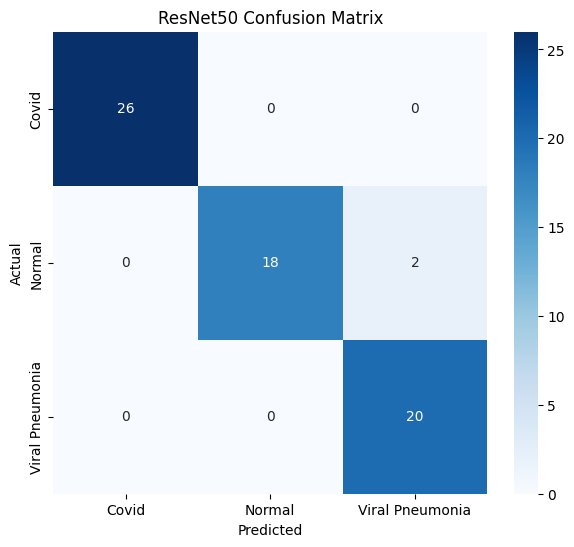

In [109]:
# Confusion matrix
resnet_cm = confusion_matrix(
    resnet_true,
    resnet_pred
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    resnet_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ResNet50 Confusion Matrix")
plt.show()

In [110]:
# ROC_AUC
resnet_auc = roc_auc_score(
    y_test_onehot,
    resnet_pred_prob,
    multi_class="ovr",
    average="weighted"
)

print("ResNet50 ROC-AUC:", resnet_auc)

ResNet50 ROC-AUC: 0.9891304347826086


In [111]:
# ResNet50 results
resnet_train_accuracy = history_resnet_fine.history["accuracy"][-1]
resnet_val_accuracy = history_resnet_fine.history["val_accuracy"][-1]

resnet_overfitting_gap = (
    resnet_train_accuracy - resnet_val_accuracy
)

print("========== RESNET50 RESULTS ==========")
print("Train Accuracy:", resnet_train_accuracy)
print("Validation Accuracy:", resnet_val_accuracy)
print("Test Accuracy:", resnet_test_accuracy)
print("F1 Score:", resnet_f1)
print("ROC-AUC:", resnet_auc)
print("Overfitting Gap:", resnet_overfitting_gap)

if resnet_overfitting_gap > 0.10:
    print("Overfitting: YES")
else:
    print("Overfitting: NO")

========== RESNET50 RESULTS ==========
Train Accuracy: 0.9950000047683716
Validation Accuracy: 0.9215686321258545
Test Accuracy: 0.9696969985961914
F1 Score: 0.9696210222526013
ROC-AUC: 0.9891304347826086
Overfitting Gap: 0.07343137264251709
Overfitting: NO


# Model Comparison Table

In [112]:
import pandas as pd

# Calculate training accuracy
basic_train_acc = history_basic.history["accuracy"][-1]
deep_train_acc = history_deep.history["accuracy"][-1]
vgg_train_acc = history_vgg.history["accuracy"][-1]
resnet_train_acc = history_resnet_fine.history["accuracy"][-1]

# Calculate overfitting gaps
basic_val_acc = history_basic.history["val_accuracy"][-1]
deep_val_acc = history_deep.history["val_accuracy"][-1]
vgg_val_acc = vgg_fine_tune.history["val_accuracy"][-1]
resnet_val_acc = history_resnet_fine.history["val_accuracy"][-1]

basic_gap = basic_train_acc - basic_val_acc
deep_gap = deep_train_acc - deep_val_acc
vgg_gap = vgg_train_acc - vgg_val_acc
resnet_gap = resnet_train_acc - resnet_val_acc

# Function to classify overfitting
def check_overfitting(gap):
    return "Yes" if gap > 0.10 else "No"

# Create comparison table
comparison_df = pd.DataFrame({
    "Model": [
        "Basic CNN",
        "Deep CNN",
        "VGG16",
        "ResNet50"
    ],

    "Train Accuracy": [
        basic_train_acc,
        deep_train_acc,
        vgg_train_acc,
        resnet_train_acc
    ],

    "Test Accuracy": [
        test_accuracy,
        deep_test_accuracy,
        vgg_test_accuracy,
        resnet_test_accuracy
    ],

    "F1 Score": [
        basic_f1,
        deep_f1,
        vgg_f1,
        resnet_f1
    ],

    "ROC-AUC": [
        basic_auc,
        deep_auc,
        vgg_auc,
        resnet_auc
    ],

    "Overfitting Gap": [
        basic_gap,
        deep_gap,
        vgg_gap,
        resnet_gap
    ],

    "Overfitting (Y/N)": [
        check_overfitting(basic_gap),
        check_overfitting(deep_gap),
        check_overfitting(vgg_gap),
        check_overfitting(resnet_gap)
    ]
})

# Format percentage columns
comparison_df["Train Accuracy"] = comparison_df["Train Accuracy"].round(4)
comparison_df["Test Accuracy"] = comparison_df["Test Accuracy"].round(4)
comparison_df["F1 Score"] = comparison_df["F1 Score"].round(4)
comparison_df["ROC-AUC"] = comparison_df["ROC-AUC"].round(4)
comparison_df["Overfitting Gap"] = comparison_df["Overfitting Gap"].round(4)

comparison_df

,Model,Train Accuracy,Test Accuracy,F1 Score,ROC-AUC,Overfitting Gap,Overfitting (Y/N)
0,Basic CNN,0.990,0.8939,0.8951,0.9706,0.1076,Yes
1,Deep CNN,0.890,0.3939,0.2227,0.7264,0.4390,Yes
2,VGG16,0.960,0.8939,0.8923,0.9750,0.0384,No
3,ResNet50,0.995,0.9697,0.9696,0.9891,0.0734,No


# Best Model

In [113]:
best_model_row = comparison_df.loc[
    comparison_df["Test Accuracy"].idxmax()
]

print("Best Model:", best_model_row["Model"])
print("Test Accuracy:", best_model_row["Test Accuracy"])
print("F1 Score:", best_model_row["F1 Score"])
print("ROC-AUC:", best_model_row["ROC-AUC"])

Best Model: ResNet50
Test Accuracy: 0.9697
F1 Score: 0.9696
ROC-AUC: 0.9891


In [114]:
best_model_name = best_model_row["Model"]

best_row = pd.DataFrame({
    "Model": [f"Best Model ({best_model_name})"],
    "Train Accuracy": [best_model_row["Train Accuracy"]],
    "Test Accuracy": [best_model_row["Test Accuracy"]],
    "F1 Score": [best_model_row["F1 Score"]],
    "ROC-AUC": [best_model_row["ROC-AUC"]],
    "Overfitting Gap": [best_model_row["Overfitting Gap"]],
    "Overfitting (Y/N)": [best_model_row["Overfitting (Y/N)"]]
})

final_comparison = pd.concat(
    [comparison_df, best_row],
    ignore_index=True
)

final_comparison

,Model,Train Accuracy,Test Accuracy,F1 Score,ROC-AUC,Overfitting Gap,Overfitting (Y/N)
0,Basic CNN,0.990,0.8939,0.8951,0.9706,0.1076,Yes
1,Deep CNN,0.890,0.3939,0.2227,0.7264,0.4390,Yes
2,VGG16,0.960,0.8939,0.8923,0.9750,0.0384,No
3,ResNet50,0.995,0.9697,0.9696,0.9891,0.0734,No
4,Best Model (ResNet50),0.995,0.9697,0.9696,0.9891,0.0734,No


# Saving ResNet50

In [115]:
resnet_model.save("covid_resnet50.keras")

In [116]:
import os

print("Model exists:", os.path.exists("covid_resnet50.keras"))
print("Model size:", os.path.getsize("covid_resnet50.keras") / (1024 * 1024), "MB")

Model exists: True
Model size: 130.70092391967773 MB


In [117]:
from google.colab import files

files.download("covid_resnet50.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>